In [11]:
import torch
import torch.nn.functional as F
from tqdm.notebook import tqdm

In [2]:
from audio_classification_playground.vox_profile.emotion.wavlm_emotion import WavLMWrapper
from audio_classification_playground.vox_profile.emotion.whisper_emotion import WhisperWrapper

/workspace/audio-classification-playground/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
# # Load model from Huggingface
# model = WavLMWrapper.from_pretrained("tiantiaf/wavlm-large-categorical-emotion").to(device)
# model = model.eval()

In [4]:
device = torch.device("cuda") if torch.cuda.is_available() else "cpu"

model = WhisperWrapper.from_pretrained("tiantiaf/whisper-large-v3-msp-podcast-emotion").to(device)
model = model.eval()

Some weights of WhisperModel were not initialized from the model checkpoint at openai/whisper-large-v3 and are newly initialized because the shapes did not match:
- encoder.embed_positions.weight: found shape torch.Size([1500, 1280]) in the checkpoint and torch.Size([750, 1280]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:
# Label List
emotion_list = [
    'Anger', 
    'Contempt', 
    'Disgust', 
    'Fear', 
    'Happiness', 
    'Neutral', 
    'Sadness', 
    'Surprise', 
    'Other'
]
len(emotion_list)

9

In [6]:
import librosa
import torch
import torch.nn.functional as F
SR = 16_000
WINDOW_SEC = 3.0
HOP_SEC = 1.0
BATCH_SIZE = 20
window_samples = int(WINDOW_SEC * SR)   # 56,000
hop_samples = int(HOP_SEC * SR)         # 16,000

In [7]:
audio_path = "/workspace/tmp_data/3d48c229-3505-4a40-b4d2-1e704aa0b8cc.mp3"
audio,_ = librosa.load(audio_path, sr=SR, mono=True)

In [8]:
audio.shape[0]/SR/60

59.03847708333333

In [9]:
# 2. Convert to tensor
audio_t = torch.from_numpy(audio).float()
# 3. Pad so the last partial window isn't silently dropped
remainder = (len(audio_t) - window_samples) % hop_samples
if remainder != 0:
    pad_needed = hop_samples - remainder
    audio_t = F.pad(audio_t, (0, pad_needed))
# 4. Unfold into overlapping windows  →  [N, window_samples]
#    unfold(dim, size, step) returns a view — no copy
windows = audio_t.unfold(0, window_samples, hop_samples)


In [ ]:
all_predicted = []
all_arousal   = []
all_valence   = []
all_dominance = []

for i in tqdm(range(0, len(windows), BATCH_SIZE)):
    batch = windows[i : i + BATCH_SIZE].to(device)
    with torch.no_grad():
        predicted, detailed_predicted, arousal, valence, dominance = model(batch, return_feature=False)
    all_predicted.append(predicted.cpu())
    all_arousal.append(arousal.cpu())
    all_valence.append(valence.cpu())
    all_dominance.append(dominance.cpu())

# single concat → [N, 9], [N, 1], [N, 1], [N, 1]
all_predicted = torch.cat(all_predicted)   # logits
all_arousal   = torch.cat(all_arousal).squeeze(-1)
all_valence   = torch.cat(all_valence).squeeze(-1)
all_dominance = torch.cat(all_dominance).squeeze(-1)

# softmax over the emotion logits
emotion_probs = F.softmax(all_predicted, dim=-1)   # [N, 9]

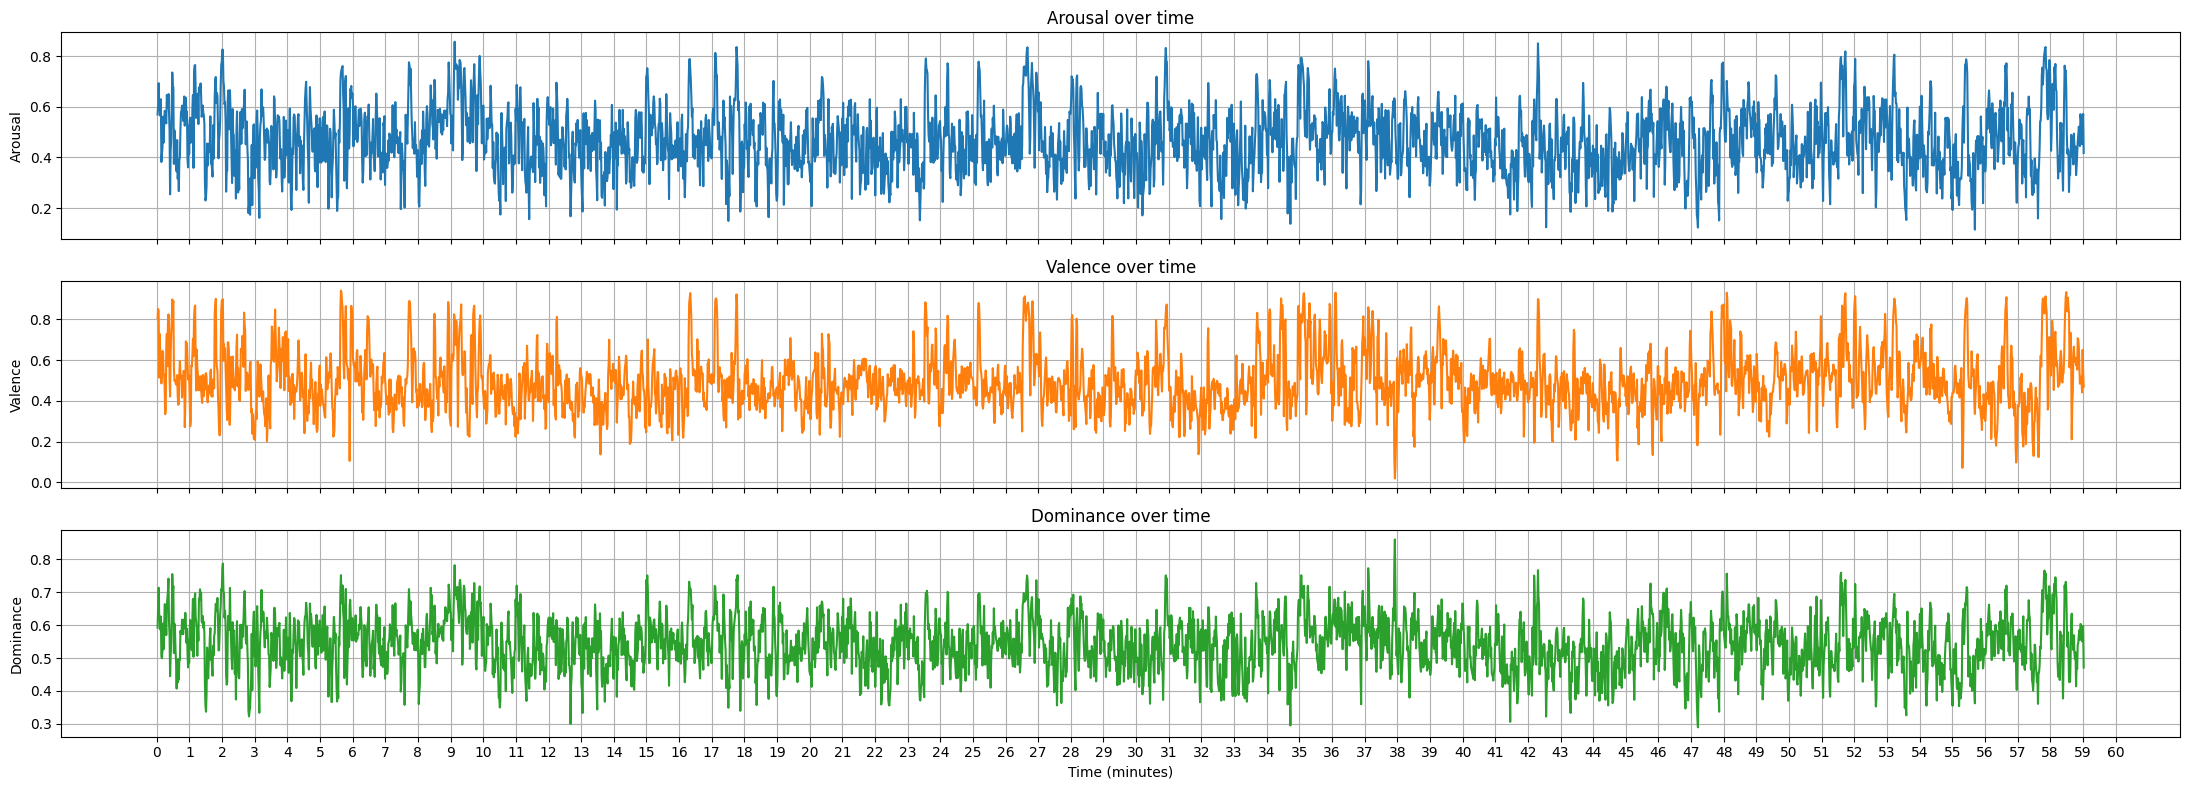

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# Compute time axis for center of each window, in seconds first
num_windows = len(all_arousal)
window_centers_sec = np.arange(num_windows) * HOP_SEC + WINDOW_SEC / 2
window_centers_min = window_centers_sec / 60.0

fig, axs = plt.subplots(3, 1, figsize=(22, 8), sharex=True)  # Widens the figure more

# Set major ticks at every minute (floor to closest integer min, up to last min)
time_min_max = window_centers_min[-1]
minute_ticks = np.arange(0, time_min_max + 1, 1)
axs[-1].set_xticks(minute_ticks)

axs[0].plot(window_centers_min, all_arousal, label="Arousal", color="tab:blue")
axs[0].set_ylabel("Arousal")
axs[0].set_title("Arousal over time")
axs[0].grid(True)
axs[0].set_xticks(minute_ticks)
axs[0].set_xticklabels([f"{tick:.0f}" for tick in minute_ticks])

axs[1].plot(window_centers_min, all_valence, label="Valence", color="tab:orange")
axs[1].set_ylabel("Valence")
axs[1].set_title("Valence over time")
axs[1].grid(True)
axs[1].set_xticks(minute_ticks)
axs[1].set_xticklabels([f"{tick:.0f}" for tick in minute_ticks])

axs[2].plot(window_centers_min, all_dominance, label="Dominance", color="tab:green")
axs[2].set_xlabel("Time (minutes)")
axs[2].set_ylabel("Dominance")
axs[2].set_title("Dominance over time")
axs[2].grid(True)
axs[2].set_xticks(minute_ticks)
axs[2].set_xticklabels([f"{tick:.0f}" for tick in minute_ticks])

# Format the x-axis as integer minutes
axs[2].xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

time_sec = np.arange(len(emotion_probs)) * HOP_SEC
time_min = time_sec / 60.0

def format_min_tick(x, _):
    """Display as M:SS"""
    m, s = divmod(int(x * 60), 60)
    return f"{m}:{s:02d}"

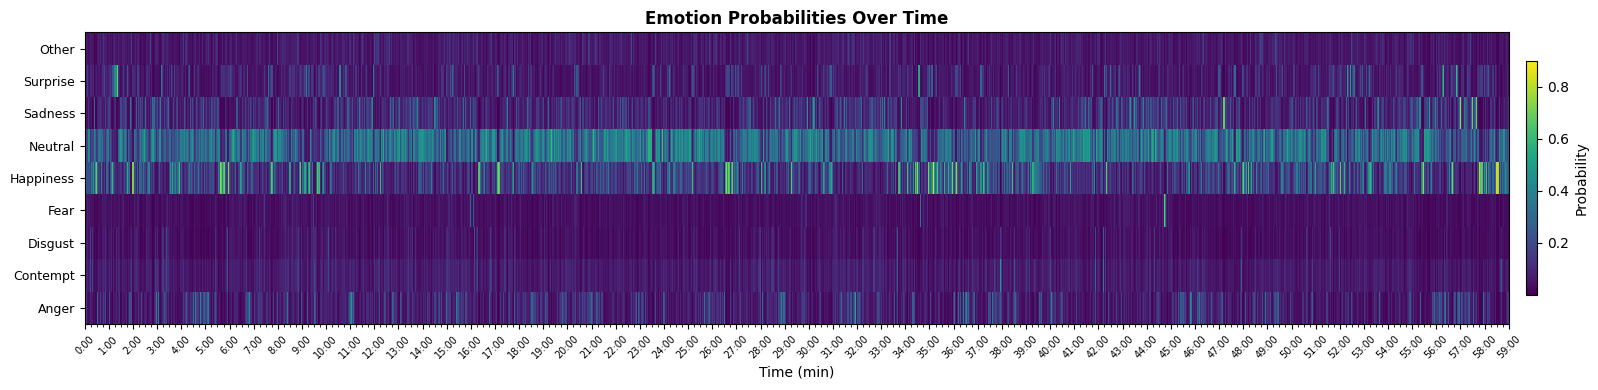

In [25]:
fig, ax = plt.subplots(figsize=(18, 4))
im = ax.imshow(
    emotion_probs.numpy().T,
    aspect="auto",
    interpolation="none",
    origin="lower",
    cmap="viridis",
    extent=[time_min[0], time_min[-1], -0.5, len(emotion_list) - 0.5],
)
ax.set_yticks(range(len(emotion_list)))
ax.set_yticklabels(emotion_list, fontsize=9)
ax.set_xlabel("Time (min)", fontsize=10)
ax.set_title("Emotion Probabilities Over Time", fontsize=12, fontweight="bold")

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))      # major every 1 min
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))   # minor every 15 sec
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_min_tick))
ax.tick_params(axis="x", which="major", labelsize=7, rotation=45)
ax.tick_params(axis="x", which="minor", length=2)

fig.colorbar(im, ax=ax, label="Probability", shrink=0.8, pad=0.01)
plt.tight_layout()
plt.show()

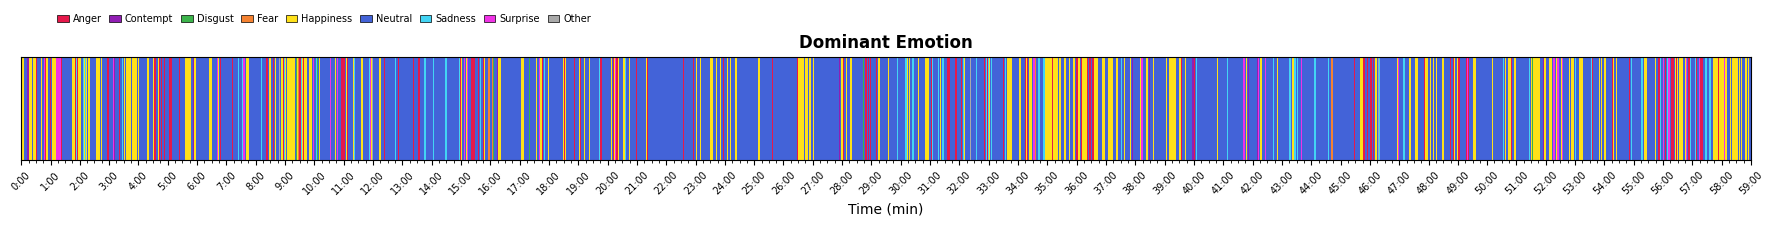

In [26]:
dominant_idx = emotion_probs.argmax(dim=-1).numpy()

# hand-picked distinct colors for 9 emotions — better than tab10 for adjacent bands
emotion_colors = [
    "#e6194b",  # Anger – red
    "#911eb4",  # Contempt – purple
    "#3cb44b",  # Disgust – green
    "#f58231",  # Fear – orange
    "#ffe119",  # Happiness – yellow
    "#4363d8",  # Neutral – blue
    "#42d4f4",  # Sadness – cyan
    "#f032e6",  # Surprise – magenta
    "#a9a9a9",  # Other – grey
]
from matplotlib.colors import ListedColormap
cmap_emo = ListedColormap(emotion_colors)

fig, ax = plt.subplots(figsize=(18, 3))

# draw as a colored bar, one pixel per window
ax.imshow(
    dominant_idx[None, :],
    aspect="auto",
    interpolation="nearest",
    cmap=cmap_emo,
    vmin=0,
    vmax=len(emotion_list) - 1,
    extent=[time_min[0], time_min[-1], 0, 1],
)
ax.set_yticks([])

# dense minute-level x ticks
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_min_tick))
ax.tick_params(axis="x", which="major", labelsize=7, rotation=45)
ax.tick_params(axis="x", which="minor", length=2)

ax.set_xlabel("Time (min)", fontsize=10)
ax.set_title("Dominant Emotion", fontsize=12, fontweight="bold")

# legend with matching colors — horizontal, compact
patches = [mpatches.Patch(facecolor=c, edgecolor="black", linewidth=0.5, label=e)
           for c, e in zip(emotion_colors, emotion_list)]
ax.legend(handles=patches, loc="lower center", bbox_to_anchor=(0.5, 1.02),
          ncol=len(emotion_list), fontsize=7, frameon=False,
          handlelength=1.2, handletextpad=0.4, columnspacing=0.8)
# Move legend to the top, right above the plot, as a horizontal band to avoid overlap
ax.legend(
    handles=patches,
    loc="upper center",
    bbox_to_anchor=(0.175, 1.5),
    ncol=len(emotion_list),
    fontsize=7,
    frameon=False,
    handlelength=1.2,
    handletextpad=0.4,
    columnspacing=0.8
)

plt.tight_layout()
plt.show()

NameError: name 'time_axis' is not defined

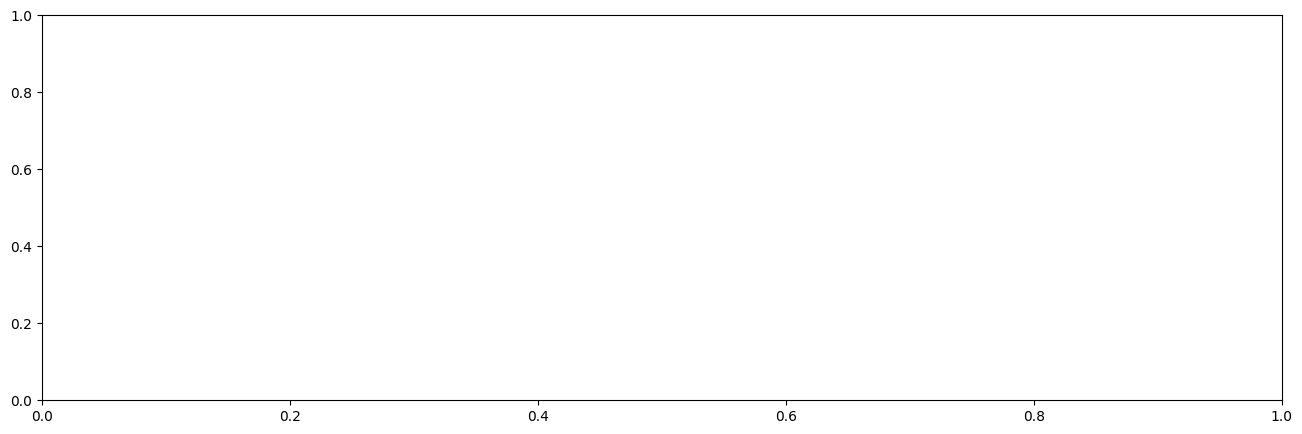

In [27]:
fig, ax = plt.subplots(figsize=(16, 5))
probs_np = emotion_probs.numpy()  # [N, 9]

ax.stackplot(
    time_axis,
    probs_np.T,                    # each row is one emotion's time series
    labels=emotion_list,
    alpha=0.85,
)
ax.set_xlim(time_axis[0], time_axis[-1])
ax.set_ylim(0, 1)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Probability")
ax.set_title("Emotion Distribution Over Time")
ax.legend(loc="upper right", fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

/workspace/tmp/ipykernel_74391/1647058969.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(emotion_list))


NameError: name 'time_axis' is not defined

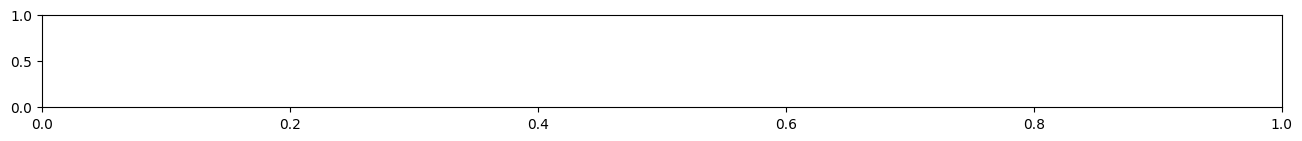

In [28]:
dominant_idx = emotion_probs.argmax(dim=-1).numpy()  # [N]

cmap = plt.cm.get_cmap("tab10", len(emotion_list))
fig, ax = plt.subplots(figsize=(16, 1.2))
ax.imshow(
    dominant_idx[None, :],          # [1, N]
    aspect="auto",
    interpolation="nearest",
    cmap=cmap,
    vmin=0, vmax=len(emotion_list) - 1,
    extent=[time_axis[0], time_axis[-1], 0, 1],
)
ax.set_yticks([])
ax.set_xlabel("Time (s)")
ax.set_title("Dominant Emotion")

# legend
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=cmap(i), label=e) for i, e in enumerate(emotion_list)]
ax.legend(handles=patches, loc="upper right", fontsize=7, ncol=len(emotion_list))
plt.tight_layout()
plt.show()

NameError: name 'time_axis' is not defined

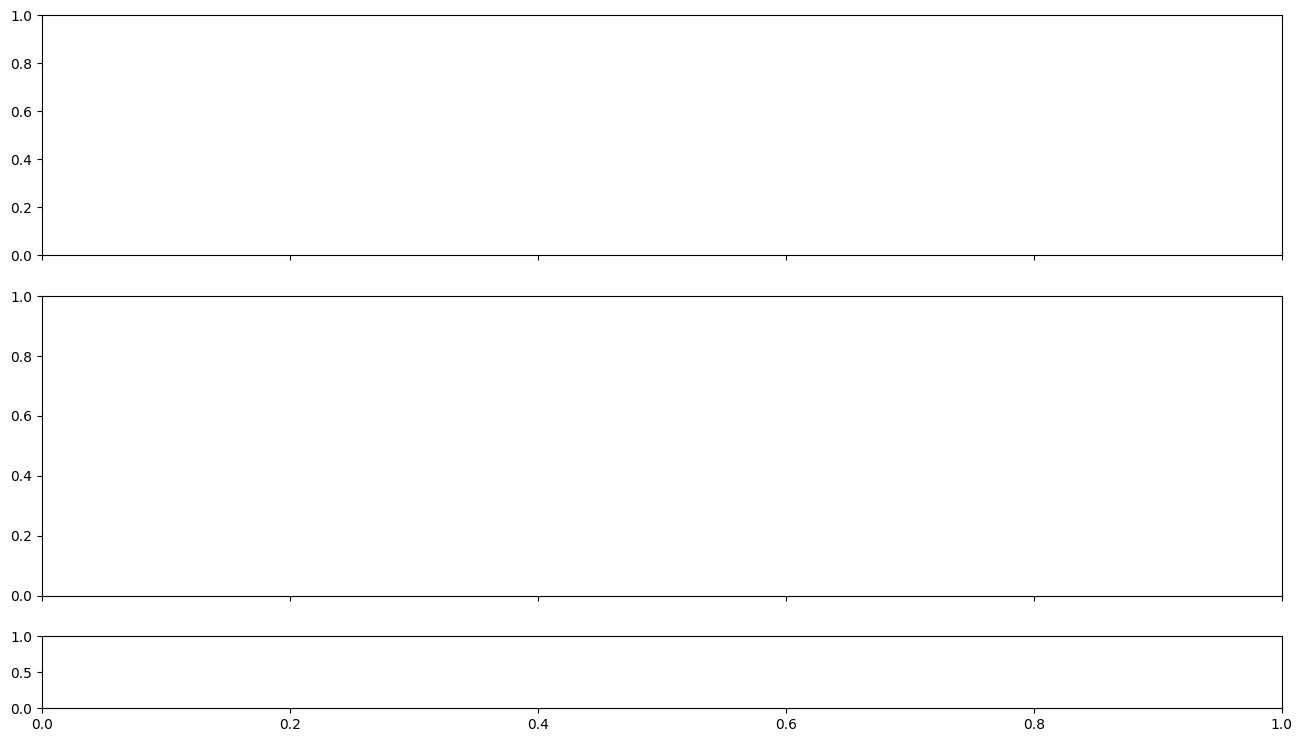

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True,
                         gridspec_kw={"height_ratios": [4, 5, 1.2]})

# -- heatmap --
im = axes[0].imshow(emotion_probs.numpy().T, aspect="auto", interpolation="none",
                    origin="lower", cmap="viridis",
                    extent=[time_axis[0], time_axis[-1], -0.5, len(emotion_list)-0.5])
axes[0].set_yticks(range(len(emotion_list)))
axes[0].set_yticklabels(emotion_list, fontsize=8)
axes[0].set_title("Probability Heatmap")
fig.colorbar(im, ax=axes[0], shrink=0.8, label="Prob")

# -- stacked area --
axes[1].stackplot(time_axis, emotion_probs.numpy().T, labels=emotion_list, alpha=0.85)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Probability")
axes[1].set_title("Stacked Distribution")
axes[1].legend(loc="upper right", fontsize=7, ncol=3)

# -- dominant strip --
cmap_dom = plt.cm.get_cmap("tab10", len(emotion_list))
axes[2].imshow(dominant_idx[None, :], aspect="auto", interpolation="nearest",
               cmap=cmap_dom, vmin=0, vmax=len(emotion_list)-1,
               extent=[time_axis[0], time_axis[-1], 0, 1])
axes[2].set_yticks([])
axes[2].set_title("Dominant Emotion")
axes[2].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()